Exception in Tkinter callback
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/tkinter/__init__.py", line 1968, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "/var/folders/qr/5mnvs57d30q1fn3bmgkp39kc0000gn/T/ipykernel_82016/1723533130.py", line 26, in load_image
    canvas(400, 300, image=loaded_image, anchor=CENTER)
TypeError: 'Canvas' object is not callable
Exception in Tkinter callback
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/tkinter/__init__.py", line 1968, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "/var/folders/qr/5mnvs57d30q1fn3bmgkp39kc0000gn/T/ipykernel_82016/1723533130.py", line 41, in convert_to_grayscale
    canvas(400, 300, image= grayscale_image, anchor=CENTER)
TypeError: 'Canvas' object is not callable
Exception in Tkinter callback
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/tkinter/__init__.py", line 1968, in __call__
    retu

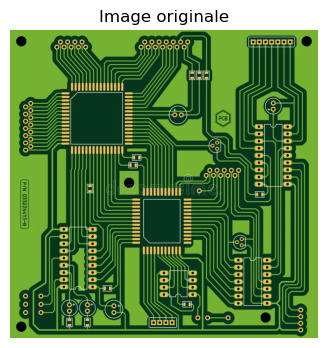

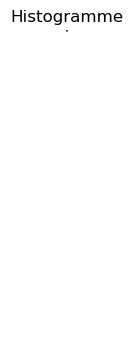

In [16]:
from tkinter import *
from tkinter import filedialog
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageTk

root = Tk()

canvas = Canvas(root, width=800, height=600, bg="white") 
canvas.pack()
# Global variable 
loaded_image = None



# Define functions for button actions
def load_image():
    global loaded_image
    loaded_image = Image.open('Circuit.png')
    plt.figure(figsize=(6, 4))
    plt.imshow(loaded_image)
    plt.axis('off')  # Remove axes
    plt.title("Image originale")
    #plt.show()
    canvas(400, 300, image=loaded_image, anchor=CENTER)
    canvas.image = loaded_image  # Conserver une référence pour éviter le garbage collectionload_image()
def convert_to_grayscale():
    global loaded_image
    if loaded_image is None:
        print("Veuillez d'abord charger une image.")
        return
    # Convert the image to grayscale
    grayscale_image = loaded_image.convert("L")
    plt.figure(figsize=(6, 4))
    plt.imshow(grayscale_image, cmap='gray')  # cmap='gray' for grayscale
    plt.axis('off')  # Remove axes
    plt.title('Image convertie en niveaux de gris')
    #plt.show()

    canvas(400, 300, image= grayscale_image, anchor=CENTER)
    canvas.image = grayscale_image  # Conserver une référence pour éviter le garbage collection
    return grayscale_image


def show_histogram():
    global loaded_image
    if loaded_image is None:
        print("Veuillez d'abord charger une image.")
        return
    # Convert to grayscale and calculate histogram
    grayscale_image = loaded_image.convert("L")
    img_array = np.array(grayscale_image).flatten()
    plt.hist(img_array, bins=256, range=(0, 256), color='gray')
    plt.title("Histogramme")
    plt.xlabel("Valeur des pixels")
    plt.ylabel("Fréquence")
    #plt.show()
    canvas(400, 300, image= grayscale_image, anchor=CENTER)
    canvas.image = grayscale_image  # Conserver une référence pour éviter le garbage collection

#  buttons 
load_button = Button(root, text="Charger l'image", command=load_image)
load_button.pack()

grayscale_button = Button(root, text="Convertir en niveaux de gris", command=convert_to_grayscale)
grayscale_button.pack()

histogram_button = Button(root, text="Afficher l'histogramme", command=show_histogram)
histogram_button.pack()

quit_button = Button(root, text="Quitter", command=root.quit)
quit_button.pack()

def load_and_display_image():
    global loaded_image, canvas
    loaded_image = Image.open('Circuit.png')
    tk_image = ImageTk.PhotoImage(loaded_image)
   
    canvas.create_image(400, 300, image=tk_image, anchor=CENTER)
    canvas.image = tk_image  


canvas = Canvas(root, width=800, height=600)
canvas.pack()

root.mainloop()